In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q codecarbon thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 384.6/384.6 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 107.7 MB/s eta 0:00:00


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random
import time

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from codecarbon import EmissionsTracker

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt

In [5]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 160
BATCH_SIZE = 64
EPOCHS = 10
SEEDS = [42, 123, 777]

torch.set_float32_matmul_precision("high")

print("="*60)
print("Dataset              : EuroSAT")
print("Input Resolution     :", IMG_SIZE)
print("Precision            : FP32")
print("Batch Size           :", BATCH_SIZE)
print("Seeds                :", SEEDS)
print("Train/Val/Test       : 70/15/15")
print("Pretrained Weights   : ImageNet-1K")
print("="*60)

print("Using device:", DEVICE)

Dataset              : EuroSAT
Input Resolution     : 160
Precision            : FP32
Batch Size           : 64
Seeds                : [42, 123, 777]
Train/Val/Test       : 70/15/15
Pretrained Weights   : ImageNet-1K
Using device: cuda


In [6]:
# --- CONFIGURATIONS & DECLARATIONS (REVIEWER COMPLIANT) ---
print("========== DATA PREPROCESSING ==========")
print(f"Dataset Name         : Oxford-IIIT Pet Dataset")
print(f"Image Resolution     : 3 x {IMG_SIZE} x {IMG_SIZE}")
print(f"Normalization Mean   : [0.485, 0.456, 0.406]")
print(f"Normalization Std    : [0.229, 0.224, 0.225]")

print("\n========== SEED CONTROL ==========")
print(f"Active Seeds         : {SEEDS}")

print("\n========== HARDWARE SPECIFICATION ==========")
print("Device allocated     :", DEVICE)
if torch.cuda.is_available():
    print("GPU Model            :", torch.cuda.get_device_name(0))
    print("Total GPU Memory     :", round(torch.cuda.get_device_properties(0).total_memory/1e9,2), "GB")

print("\n========== NUMERICAL PRECISION ==========")
print("Training Precision   : FP32")

print("\n========== BATCH SCHEDULING ==========")
print(f"Mini-Batch Size      : {BATCH_SIZE}")
print("Gradient Update      : Step-by-Step (Every Batch)")

========== DATA PREPROCESSING ==========
Dataset Name         : Oxford-IIIT Pet Dataset
Image Resolution     : 3 x 160 x 160
Normalization Mean   : [0.485, 0.456, 0.406]
Normalization Std    : [0.229, 0.224, 0.225]

========== SEED CONTROL ==========
Active Seeds         : [42, 123, 777]

========== HARDWARE SPECIFICATION ==========
Device allocated     : cuda
GPU Model            : Tesla T4
Total GPU Memory     : 15.64 GB

========== NUMERICAL PRECISION ==========
Training Precision   : FP32

========== BATCH SCHEDULING ==========
Mini-Batch Size      : 64
Gradient Update      : Step-by-Step (Every Batch)


In [7]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [8]:
transform = transforms.Compose([
    transforms.Resize((160,160)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [9]:
DATA_DIR = "/content/drive/MyDrive/EuroSAT_RGB/EuroSAT"



In [10]:
set_seed(42)

dataset = datasets.ImageFolder(DATA_DIR, transform=transform)

train_size = int(0.70 * len(dataset))
val_size   = int(0.15 * len(dataset))
test_size  = len(dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print("\n========== DATASET SPLIT ==========")
print(f"Total Images : {len(dataset)}")
print(f"Train Images : {len(train_dataset)}")
print(f"Val Images   : {len(val_dataset)}")
print(f"Test Images  : {len(test_dataset)}")
print(f"Classes      : {dataset.classes}")


========== DATASET SPLIT ==========
Total Images : 27000
Train Images : 18900
Val Images   : 4050
Test Images  : 4050
Classes      : ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


In [11]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [12]:
# ==========================================================
# EXPERIMENT DECLARATION
# ==========================================================

print("\n========== EXPERIMENT CONFIGURATION ==========")

print(f"Model              : EfficientNet-B0")
print(f"Input Resolution   : {IMG_SIZE} x {IMG_SIZE}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Epochs             : {EPOCHS}")
print(f"Precision          : FP32")
print(f"Seeds              : {SEEDS}")
print(f"Dataset Split      : 70/15/15")


========== EXPERIMENT CONFIGURATION ==========
Model              : EfficientNet-B0
Input Resolution   : 160 x 160
Batch Size         : 64
Epochs             : 10
Precision          : FP32
Seeds              : [42, 123, 777]
Dataset Split      : 70/15/15


In [13]:
print("\n========== NUMERICAL PRECISION ==========")
print("Training Precision : FP32")


========== NUMERICAL PRECISION ==========
Training Precision : FP32


In [14]:
print("\n========== INPUT RESOLUTION ==========")
print(f"Input Size = {IMG_SIZE} x {IMG_SIZE}")


========== INPUT RESOLUTION ==========
Input Size = 160 x 160


In [15]:
# ==========================================================
# EFFICIENTNET JUSTIFICATION
# ==========================================================

print("\n========== EFFICIENTNET-B0 JUSTIFICATION ==========")

print("""
EfficientNet-B0 is selected because it employs
compound scaling, which jointly scales:

1. Network Depth
2. Network Width
3. Input Resolution

This enables better accuracy-efficiency tradeoff
compared to conventional CNN scaling methods.
""")


========== EFFICIENTNET-B0 JUSTIFICATION ==========

EfficientNet-B0 is selected because it employs
compound scaling, which jointly scales:

1. Network Depth
2. Network Width
3. Input Resolution

This enables better accuracy-efficiency tradeoff
compared to conventional CNN scaling methods.



In [16]:
import torch.nn as nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

def get_efficientnet(num_classes=10):
    # Reviewer Compliance: Explicit Justification for EfficientNet-B0
    print("\n========== MODEL JUSTIFICATION ==========")
    print("Model Architecture   : EfficientNet-B0")
    print("Scaling Mechanism    : Compound Scaling (Uniformly scales Depth, Width, and Resolution via fixed coefficients)")
    print("Compound Coefficients: alpha=1.2, beta=1.1, gamma=1.15")

    weights = EfficientNet_B0_Weights.IMAGENET1K_V1
    model = efficientnet_b0(weights=weights)

    # Freeze all layers initially
    for param in model.parameters():
        param.requires_grad = False

    # Partial fine-tuning: Unfreeze last block (features.8)
    for name, param in model.named_parameters():
        if "features.8" in name:
            param.requires_grad = True

    # Replace classifier head
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    # Reviewer Compliance: Explicit Freeze/Unfreeze Parameter Counting
    frozen_params = 0
    trainable_params = 0
    for param in model.parameters():
        if param.requires_grad:
            trainable_params += param.numel()
        else:
            frozen_params += param.numel()

    print("\n========== TRANSFER LEARNING STATUS ==========")
    print(f"Frozen Parameters    : {frozen_params:,}")
    print(f"Trainable Parameters : {trainable_params:,}")
    print(f"Total Parameters     : {frozen_params + trainable_params:,}")
    print("----------------------------------------------")

    return model.to(DEVICE)

In [17]:
import torch
from thop import profile  # <-- Yeh import line zaroori hai!

def calculate_flops():
    model = get_efficientnet()  # Ensure num_classes aur DEVICE properly set hain
    dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

    # thop library ka profile function ab chalega
    flops, params = profile(model, inputs=(dummy,), verbose=False)
    return flops/1e9, params/1e6

gflops, mparams = calculate_flops()

print(f"FLOPs : {gflops:.3f} GFLOPs")
print(f"Params: {mparams:.2f} M")


========== MODEL JUSTIFICATION ==========
Model Architecture   : EfficientNet-B0
Scaling Mechanism    : Compound Scaling (Uniformly scales Depth, Width, and Resolution via fixed coefficients)
Compound Coefficients: alpha=1.2, beta=1.1, gamma=1.15
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 115MB/s] 



========== TRANSFER LEARNING STATUS ==========
Frozen Parameters    : 3,595,388
Trainable Parameters : 424,970
Total Parameters     : 4,020,358
----------------------------------------------
FLOPs : 0.211 GFLOPs
Params: 4.02 M


In [18]:
print("\n========== BATCH SCHEDULING ==========")
print(f"Mini Batch Size : {BATCH_SIZE}")
print("Gradient Update : Every Batch")
# Reviewer Compliance: CodeCarbon Configuration Declaration
print("\n========== CODECARBON CONFIGURATION ==========")
print("Tracking Mode        : Environment/Process Level")
print("Project Name         : EfficientNetB0_Pet_Classification")
print("----------------------------------------------")

tracker = EmissionsTracker(project_name="EfficientNetB0_Pet_Classification", measure_power_secs=15, tracking_mode='process')

[codecarbon WARNING @ 02:52:33] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 02:52:33] [setup] RAM Tracking...
[codecarbon INFO @ 02:52:33] [setup] CPU Tracking...



========== BATCH SCHEDULING ==========
Mini Batch Size : 64
Gradient Update : Every Batch

========== CODECARBON CONFIGURATION ==========
Tracking Mode        : Environment/Process Level
Project Name         : EfficientNetB0_Pet_Classification
----------------------------------------------


[codecarbon WARNING @ 02:52:34] We saw that you have a Intel(R) Xeon(R) CPU @ 2.00GHz but we don't know it. Please contact us.
[codecarbon WARNING @ 02:52:34] We will use the default power consumption of 4 W per thread for your 2 CPU, so 8W.
[codecarbon WARNING @ 02:52:34] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist, and are readable, at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 02:52:34] CPU Model on constant consumption mode: Intel(R) Xeon(R) CPU @ 2.00GHz
[codecarbon WARNING @ 02:52:34] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 02:52:34] [setup] GPU Tracking...
[codecarbon INFO @ 02:52:34] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 02:52:34] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking 

In [19]:
def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            preds = torch.argmax(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_loss = running_loss / len(loader)
    val_acc = correct / total
    return val_loss, val_acc, all_labels, all_preds

In [20]:
import time
from sklearn.metrics import precision_recall_fscore_support

def train_and_evaluate_efficientnet(seed, num_epochs=10):
    set_seed(seed)
    start_time = time.time()

    # FIX: Agar global variables pehle se defined hain, toh call karne ki zaroorat nahi hai
    # Hame bas unhe use karna hai (train_loader, val_loader, test_loader automatic mil jayenge)
    model = get_efficientnet()

    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=3e-4)
    criterion = nn.CrossEntropyLoss()

    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []

    for epoch in range(num_epochs):
        # --- TRAINING PHASE ---
        model.train()
        running_train_loss = 0.0
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()
            preds = torch.argmax(outputs, 1)
            train_correct += (preds == labels).sum().item()
            train_total += labels.size(0)

        epoch_train_loss = running_train_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total
        train_losses.append(epoch_train_loss)
        train_accs.append(epoch_train_acc)

        # --- VALIDATION PHASE ---
        val_loss, val_acc, _, _ = validate(model, val_loader, criterion)
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1:02d}/{num_epochs:02d} | Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    # --- FINAL INDEPENDENT TEST EVALUATION ---
    print("\nExecuting Independent Test Evaluation...")
    test_loss, test_acc, y_true, y_pred = validate(model, test_loader, criterion)

    # Calculate Sklearn Metrics for the final test set
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)

    runtime = time.time() - start_time

    return (
        test_acc,
        prec,
        rec,
        f1,
        runtime,
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        y_true,
        y_pred
    )

In [ ]:
# ==========================================================
# MULTI-SEED EVALUATION + CO2 TRACKING (EFFICIENTNET)
# ==========================================================
results = []
tracker = EmissionsTracker(
    project_name="EfficientNetB0_GreenAI",
    tracking_mode="process",
    measure_power_secs=1,
    log_level="error"
)
tracker.start()

# In variables ko loop se pehle bahar empty define karein taaki plots smoothly run hon
latest_train_losses = []
latest_val_losses = []
latest_train_accs = []
latest_val_accs = []
final_y_true = []
final_y_pred = []

for seed in SEEDS:
    print(f"\nRunning Seed: {seed}")
    (
        acc,
        prec,
        rec,
        f1,
        runtime,
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        y_true,
        y_pred
    ) = train_and_evaluate_efficientnet(seed)

    results.append([
        float(acc),
        float(prec),
        float(rec),
        float(f1),
        float(runtime)
    ])

    # Har iteration me overwrite hoga, jisse automatic last successful run ka plot banega
    latest_train_losses = train_losses
    latest_val_losses = val_losses
    latest_train_accs = train_accs
    latest_val_accs = val_accs
    final_y_true = y_true
    final_y_pred = y_pred

# ==========================================================
# CO2 EMISSION
# ==========================================================
co2 = tracker.stop()
if co2 is None:
    co2 = 0.0

print("\n==============================")
print(f"CO2 Emission : {co2:.6f} kg CO2eq")
print("==============================")

if len(results) == 0:
    raise ValueError("No successful runs completed.")

results = np.array(results)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================
print("\n========== CLASSIFICATION REPORT ==========\n")
print(classification_report(final_y_true, final_y_pred, zero_division=0))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================
print("\n========== CONFUSION MATRIX ==========\n")
cm = confusion_matrix(final_y_true, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (EfficientNet)")
plt.show()

# ==========================================================
# LOSS CURVE
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(latest_train_losses, label="Train Loss")
plt.plot(latest_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (EfficientNet)")
plt.legend()
plt.show()

# ==========================================================
# ACCURACY CURVE
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(latest_train_accs, label="Train Accuracy")
plt.plot(latest_val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (EfficientNet)")
plt.legend()
plt.show()

# ==========================================================
# FINAL RESULTS (MEAN ± SD)
# ==========================================================
print("\n========== FINAL RESULTS ==========\n")
print(f"Accuracy  : {results[:,0].mean():.4f} ± {results[:,0].std():.4f}")
print(f"Precision : {results[:,1].mean():.4f} ± {results[:,1].std():.4f}")
print(f"Recall    : {results[:,2].mean():.4f} ± {results[:,2].std():.4f}")
print(f"F1 Score  : {results[:,3].mean():.4f} ± {results[:,3].std():.4f}")
print(f"Runtime   : {results[:,4].mean():.2f} ± {results[:,4].std():.2f} sec")
print(f"CO2       : {co2:.6f} kg CO2eq")


Running Seed: 42

========== MODEL JUSTIFICATION ==========
Model Architecture   : EfficientNet-B0
Scaling Mechanism    : Compound Scaling (Uniformly scales Depth, Width, and Resolution via fixed coefficients)
Compound Coefficients: alpha=1.2, beta=1.1, gamma=1.15

========== TRANSFER LEARNING STATUS ==========
Frozen Parameters    : 3,595,388
Trainable Parameters : 424,970
Total Parameters     : 4,020,358
----------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | Train Loss: 0.6666 | Train Acc: 0.8285 | Val Loss: 0.2638 | Val Acc: 0.9212
Epoch 02/10 | Train Loss: 0.2896 | Train Acc: 0.9072 | Val Loss: 0.2023 | Val Acc: 0.9363
Epoch 03/10 | Train Loss: 0.2290 | Train Acc: 0.9258 | Val Loss: 0.1791 | Val Acc: 0.9427
Epoch 04/10 | Train Loss: 0.1932 | Train Acc: 0.9363 | Val Loss: 0.1633 | Val Acc: 0.9469
Epoch 05/10 | Train Loss: 0.1686 | Train Acc: 0.9454 | Val Loss: 0.1484 | Val Acc: 0.9519
Epoch 06/10 | Train Loss: 0.1500 | Train Acc: 0.9511 | Val Loss: 0.1503 | Val Acc: 0.9501
Epoch 07/10 | Train Loss: 0.1391 | Train Acc: 0.9563 | Val Loss: 0.1435 | Val Acc: 0.9536
Epoch 08/10 | Train Loss: 0.1268 | Train Acc: 0.9590 | Val Loss: 0.1405 | Val Acc: 0.9553
Epoch 09/10 | Train Loss: 0.1183 | Train Acc: 0.9623 | Val Loss: 0.1348 | Val Acc: 0.9538
Epoch 10/10 | Train Loss: 0.1080 | Train Acc: 0.9641 | Val Loss: 0.1248 | Val Acc: 0.9590

Executing Independent Test Evaluation...

Running Seed: 123

========== MODEL JUSTIFICATION =======

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | Train Loss: 0.6705 | Train Acc: 0.8277 | Val Loss: 0.2801 | Val Acc: 0.9163
Epoch 02/10 | Train Loss: 0.2840 | Train Acc: 0.9093 | Val Loss: 0.2021 | Val Acc: 0.9358
Epoch 03/10 | Train Loss: 0.2291 | Train Acc: 0.9246 | Val Loss: 0.1805 | Val Acc: 0.9427
Epoch 04/10 | Train Loss: 0.1932 | Train Acc: 0.9366 | Val Loss: 0.1619 | Val Acc: 0.9494
Epoch 05/10 | Train Loss: 0.1751 | Train Acc: 0.9412 | Val Loss: 0.1558 | Val Acc: 0.9501
Epoch 06/10 | Train Loss: 0.1508 | Train Acc: 0.9501 | Val Loss: 0.1421 | Val Acc: 0.9521
Epoch 07/10 | Train Loss: 0.1419 | Train Acc: 0.9538 | Val Loss: 0.1418 | Val Acc: 0.9548
Epoch 08/10 | Train Loss: 0.1292 | Train Acc: 0.9580 | Val Loss: 0.1419 | Val Acc: 0.9523
Epoch 09/10 | Train Loss: 0.1077 | Train Acc: 0.9646 | Val Loss: 0.1337 | Val Acc: 0.9531
Epoch 10/10 | Train Loss: 0.1079 | Train Acc: 0.9650 | Val Loss: 0.1317 | Val Acc: 0.9551

Executing Independent Test Evaluation...

Running Seed: 777

========== MODEL JUSTIFICATION =======

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01/10 | Train Loss: 0.6657 | Train Acc: 0.8275 | Val Loss: 0.2784 | Val Acc: 0.9153
Epoch 02/10 | Train Loss: 0.2858 | Train Acc: 0.9091 | Val Loss: 0.2055 | Val Acc: 0.9378
Epoch 03/10 | Train Loss: 0.2329 | Train Acc: 0.9253 | Val Loss: 0.1761 | Val Acc: 0.9402
Epoch 04/10 | Train Loss: 0.1985 | Train Acc: 0.9358 | Val Loss: 0.1681 | Val Acc: 0.9457


In [21]:
# ==========================================================
# MULTI-SEED EVALUATION + CO2 TRACKING (EFFICIENTNET)
# ==========================================================
results = []
tracker = EmissionsTracker(
    project_name="EfficientNetB0_GreenAI",
    tracking_mode="process",
    measure_power_secs=1,
    log_level="error"
)
tracker.start()

# In variables ko loop se pehle bahar empty define karein taaki plots smoothly run hon
latest_train_losses = []
latest_val_losses = []
latest_train_accs = []
latest_val_accs = []
final_y_true = []
final_y_pred = []

for seed in SEEDS:
    print(f"\nRunning Seed: {seed}")
    (
        acc,
        prec,
        rec,
        f1,
        runtime,
        train_losses,
        val_losses,
        train_accs,
        val_accs,
        y_true,
        y_pred
    ) = train_and_evaluate_efficientnet(seed)

    results.append([
        float(acc),
        float(prec),
        float(rec),
        float(f1),
        float(runtime)
    ])

    # Har iteration me overwrite hoga, jisse automatic last successful run ka plot banega
    latest_train_losses = train_losses
    latest_val_losses = val_losses
    latest_train_accs = train_accs
    latest_val_accs = val_accs
    final_y_true = y_true
    final_y_pred = y_pred

# ==========================================================
# CO2 EMISSION
# ==========================================================
co2 = tracker.stop()
if co2 is None:
    co2 = 0.0

print("\n==============================")
print(f"CO2 Emission : {co2:.6f} kg CO2eq")
print("==============================")

if len(results) == 0:
    raise ValueError("No successful runs completed.")

results = np.array(results)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================
print("\n========== CLASSIFICATION REPORT ==========\n")
print(classification_report(final_y_true, final_y_pred, zero_division=0))

# ==========================================================
# CONFUSION MATRIX
# ==========================================================
print("\n========== CONFUSION MATRIX ==========\n")
cm = confusion_matrix(final_y_true, final_y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (EfficientNet)")
plt.show()

# ==========================================================
# LOSS CURVE
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(latest_train_losses, label="Train Loss")
plt.plot(latest_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (EfficientNet)")
plt.legend()
plt.show()

# ==========================================================
# ACCURACY CURVE
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(latest_train_accs, label="Train Accuracy")
plt.plot(latest_val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (EfficientNet)")
plt.legend()
plt.show()

# ==========================================================
# FINAL RESULTS (MEAN ± SD)
# ==========================================================
print("\n========== FINAL RESULTS ==========\n")
print(f"Accuracy  : {results[:,0].mean():.4f} ± {results[:,0].std():.4f}")
print(f"Precision : {results[:,1].mean():.4f} ± {results[:,1].std():.4f}")
print(f"Recall    : {results[:,2].mean():.4f} ± {results[:,2].std():.4f}")
print(f"F1 Score  : {results[:,3].mean():.4f} ± {results[:,3].std():.4f}")
print(f"Runtime   : {results[:,4].mean():.2f} ± {results[:,4].std():.2f} sec")
print(f"CO2       : {co2:.6f} kg CO2eq")

[codecarbon WARNING @ 02:52:45] Multiple instances of codecarbon are allowed to run at the same time.



Running Seed: 42

========== MODEL JUSTIFICATION ==========
Model Architecture   : EfficientNet-B0
Scaling Mechanism    : Compound Scaling (Uniformly scales Depth, Width, and Resolution via fixed coefficients)
Compound Coefficients: alpha=1.2, beta=1.1, gamma=1.15

========== TRANSFER LEARNING STATUS ==========
Frozen Parameters    : 3,595,388
Trainable Parameters : 424,970
Total Parameters     : 4,020,358
----------------------------------------------
Epoch 01/10 | Train Loss: 0.6617 | Train Acc: 0.8326 | Val Loss: 0.2646 | Val Acc: 0.9188
Epoch 02/10 | Train Loss: 0.2884 | Train Acc: 0.9064 | Val Loss: 0.2026 | Val Acc: 0.9343
Epoch 03/10 | Train Loss: 0.2276 | Train Acc: 0.9265 | Val Loss: 0.1817 | Val Acc: 0.9410
Epoch 04/10 | Train Loss: 0.1971 | Train Acc: 0.9349 | Val Loss: 0.1651 | Val Acc: 0.9452
Epoch 05/10 | Train Loss: 0.1660 | Train Acc: 0.9450 | Val Loss: 0.1540 | Val Acc: 0.9519
Epoch 06/10 | Train Loss: 0.1543 | Train Acc: 0.9484 | Val Loss: 0.1473 | Val Acc: 0.9509
Ep

NameError: name 'sns' is not defined

<Figure size 800x600 with 0 Axes>


========== CONFUSION MATRIX ==========



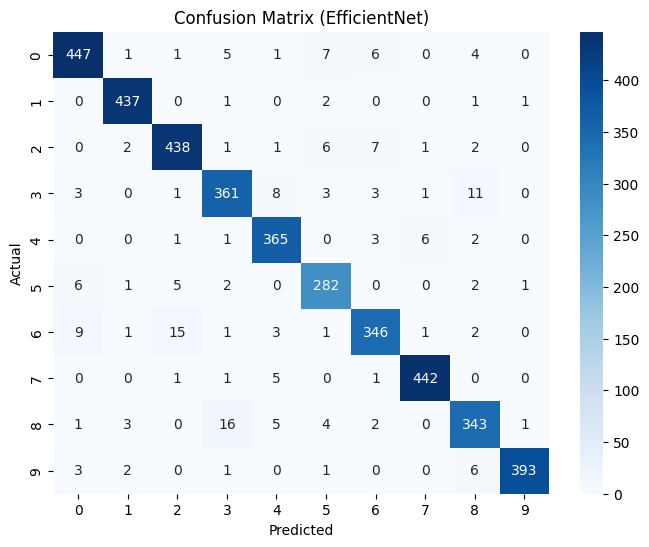

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("\n========== CONFUSION MATRIX ==========\n")

cm = confusion_matrix(final_y_true, final_y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (EfficientNet)")
plt.show()

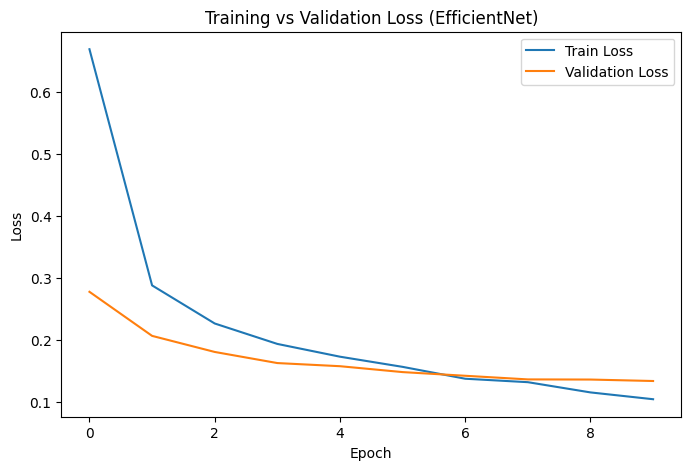

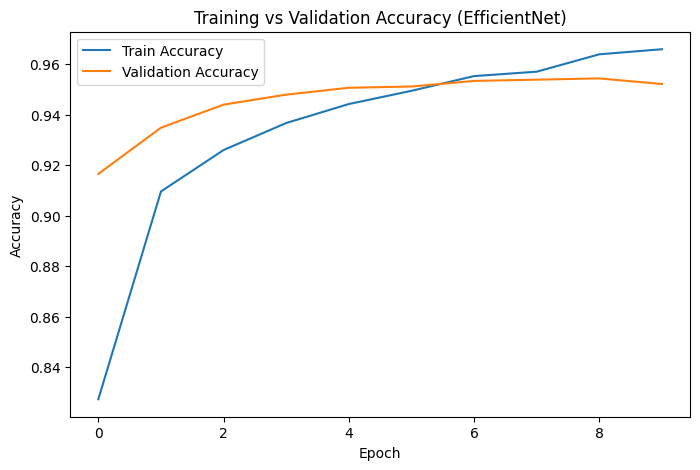


========== FINAL RESULTS ==========

Accuracy  : 0.9531 ± 0.0011
Precision : 0.9517 ± 0.0014
Recall    : 0.9517 ± 0.0013
F1 Score  : 0.9516 ± 0.0013
Runtime   : 2761.56 ± 2647.86 sec
CO2       : 0.038109 kg CO2eq


In [23]:
# ==========================================================
# LOSS CURVE
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(latest_train_losses, label="Train Loss")
plt.plot(latest_val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (EfficientNet)")
plt.legend()
plt.show()

# ==========================================================
# ACCURACY CURVE
# ==========================================================
plt.figure(figsize=(8, 5))
plt.plot(latest_train_accs, label="Train Accuracy")
plt.plot(latest_val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy (EfficientNet)")
plt.legend()
plt.show()

# ==========================================================
# FINAL RESULTS (MEAN ± SD)
# ==========================================================
print("\n========== FINAL RESULTS ==========\n")
print(f"Accuracy  : {results[:,0].mean():.4f} ± {results[:,0].std():.4f}")
print(f"Precision : {results[:,1].mean():.4f} ± {results[:,1].std():.4f}")
print(f"Recall    : {results[:,2].mean():.4f} ± {results[:,2].std():.4f}")
print(f"F1 Score  : {results[:,3].mean():.4f} ± {results[:,3].std():.4f}")
print(f"Runtime   : {results[:,4].mean():.2f} ± {results[:,4].std():.2f} sec")
print(f"CO2       : {co2:.6f} kg CO2eq")